In [ ]:
##### import numpy as np
import pandas as pd
from scipy import integrate
from scipy.special import logsumexp
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pastislib as pl
import chib as chib
import perrakis as perr
import lib
import numpy as n
import matplotlib.pylab as plt

from math import e, log10

def log_likelihood(theta):
    theta_params = theta[:-1]      # model parameters
    sigma = theta[-1]              # noise std
    
    if sigma <= 0:
        return -np.inf
    
    # compute sum of squared residuals
    ssr = 0.0
    for x, y in data_int:
        ssr += (y - f(x, theta_params))**2
        if not np.isfinite(ssr) or np.isnan(ssr):
            print('Nan in func',y,x,theta_params,f(x, theta_params))
    
    n = len(data_int)
    return -n * np.log(sigma*np.sqrt(2*np.pi)) - ssr/(2*sigma**2)

def lnlikefunc(theta):
    theta = np.atleast_2d(theta)
    out = np.empty(len(theta))
    for i, th in enumerate(theta):
        sigma = np.exp(th[-1])
        out[i] = log_likelihood(np.append(th[:-1], sigma))
    return out


def log_prior_theta(theta, eps=100.0):
    d = len(theta)
    return -0.5*np.sum(theta**2)/eps**2 - d*np.log(np.sqrt(2*np.pi)*eps)
def log_prior_sigma(sigma):
    if sigma <= 0:
        return -np.inf
    return -np.log(sigma)


def log_target(theta):
    return log_likelihood(theta) + log_prior_theta(theta[:-1]) + log_prior_sigma(theta[-1])

def log_posterior(theta):
    theta_params = theta[:-1]
    sigma = theta[-1]
    return log_likelihood(theta) + log_prior_theta(theta_params) + log_prior_sigma(sigma)

# ---------------------------------------------------
# 2. Chib-Jeliazkov estimator
# ---------------------------------------------------
def chib_jeliazkov(samples, log_likelihood, log_prior_theta, log_prior_sigma, theta_star=None):
    """
    Estimate log marginal likelihood using Chib & Jeliazkov (2001)
    samples: MCMC samples, shape (n_samples, n_params+1)
    theta_star: optional point to evaluate posterior (default: posterior mean)
    """
    if theta_star is None:
        theta_star = np.mean(samples, axis=0)
        print(theta_star)
    
    # numerator: log p(y|theta*) + log p(theta*)
    log_num = log_likelihood(theta_star) + log_prior_theta(theta_star[:-1]) + log_prior_sigma(theta_star[-1])
    
    # posterior density at theta_star: estimate with kernel density over MCMC
    # We'll use a multivariate normal approximation to the posterior
    cov = np.cov(samples.T)
    log_posterior_est = multivariate_normal.logpdf(theta_star, mean=np.mean(samples, axis=0), cov=cov)
    
    log_marginal = log_num - log_posterior_est
    return log_marginal


def chib_jeliazkov_mh(samples, theta_star, log_likelihood, log_prior, proposal_sampler, proposal_pdf, n_proposals=1000):
    """
    Chib-Jeliazkov estimator for log marginal likelihood using Metropolis-Hastings samples.
    
    Parameters
    ----------
    samples : np.ndarray
        Posterior samples from MH, shape (n_samples, d)
    theta_star : np.ndarray
        Point at which to evaluate posterior ordinate (e.g., a high posterior density point)
    log_likelihood : function(theta)
        Log-likelihood function
    log_prior : function(theta)
        Log-prior function
    proposal_sampler : function(theta_current) -> theta_proposal
        Function to sample from MH proposal distribution q(theta_current, .)
    proposal_pdf : function(theta_new, theta_old) -> float
        Proposal density q(theta_new | theta_old)
    n_proposals : int
        Number of proposals from theta_star to compute denominator
    
    Returns
    -------
    log_marginal : float
        Log marginal likelihood estimate
    """
    
    # -------- Numerator: E_{theta ~ posterior}[alpha(theta, theta_star) * q(theta -> theta_star)] --------
    alpha_vals = []
    for theta in samples:
        # MH acceptance probability alpha(theta -> theta_star)
        log_num = log_likelihood(theta_star) + log_prior(theta_star)
        log_den = log_likelihood(theta) + log_prior(theta)
        log_alpha = log_num - log_den
        alpha = min(1, np.exp(log_alpha))
        # Multiply by proposal density q(theta -> theta_star)
        alpha_vals.append(alpha * proposal_pdf(theta_star, theta))
    
    numerator = np.mean(alpha_vals)
    
    # -------- Denominator: E_{theta' ~ q(theta_star, .)}[alpha(theta_star -> theta')] --------
    alpha_star_vals = []
    for _ in range(n_proposals):
        theta_prop = proposal_sampler(theta_star)
        log_num = log_likelihood(theta_prop) + log_prior(theta_prop)
        log_den = log_likelihood(theta_star) + log_prior(theta_star)
        log_alpha = log_num - log_den
        alpha_star = min(1, np.exp(log_alpha))
        alpha_star_vals.append(alpha_star)
    
    denominator = np.mean(alpha_star_vals)
    
    # Posterior ordinate at theta_star
    p_theta_star = numerator / denominator
    
    # Log marginal likelihood
    log_marginal = log_likelihood(theta_star) + log_prior(theta_star) - np.log(p_theta_star)
    
    return log_marginal



# ---------------------------------------------------
# 3. Perrakis estimator
# ---------------------------------------------------
def perrakis_estimator(samples, log_likelihood, log_prior_theta, log_prior_sigma):
    """
    Estimate log marginal likelihood using Perrakis et al. (2014)
    """
    n_samples, d = samples.shape
    
    # Estimate posterior marginals for each parameter using KDE
    from scipy.stats import gaussian_kde
    log_marginals = []
    for i in range(d):
        kde = gaussian_kde(samples[:, i])
        log_marginals.append(np.log(kde.evaluate(samples[:, i]) + 1e-300))  # avoid log(0)
    log_marginals = np.array(log_marginals).T  # shape (n_samples, d)
    
    # log p(y, theta) - sum log p(theta_i | y)
    log_joint = np.array([log_likelihood(theta) +
                          log_prior_theta(theta[:-1]) +
                          log_prior_sigma(theta[-1]) for theta in samples])
    
    log_ratios = log_joint - log_marginals.sum(axis=1)
    
    # Perrakis estimate
    log_marginal = np.log(np.mean(np.exp(log_ratios)))
    return log_marginal

# ---------------------------------------------------
# 4. Bridge sampling
# ---------------------------------------------------
def bridge_sampling(samples, log_likelihood, log_prior_theta, log_prior_sigma):
    """
    Simple bridge sampling approximation
    """
    n_samples, d = samples.shape
    theta_mean = np.mean(samples, axis=0)
    theta_cov = np.cov(samples.T)
    
    # proposal distribution: multivariate normal
    def log_proposal(theta):
        return multivariate_normal.logpdf(theta, mean=theta_mean, cov=theta_cov)
    
    log_post = np.array([log_posterior(theta) for theta in samples])
    log_prop = np.array([log_proposal(theta) for theta in samples])
    
    # Bridge estimator: log marginal ~ log(mean(exp(log_post - log_prop)))
    log_marginal = np.log(np.mean(np.exp(log_post - log_prop)))
    return log_marginal

def metropolis_hastings(log_posterior, theta_init, n_samples, proposal_cov=None, burn_in=0, thinning=1):
    """
    General Metropolis-Hastings MCMC sampler.
    
    Parameters:
    -----------
    log_posterior : function(theta) -> float
        Log posterior function: log(p(y|theta) * p(theta))
    theta_init : np.array
        Initial parameter vector
    n_samples : int
        Number of MCMC samples to return (after burn-in and thinning)
    proposal_cov : np.array (d x d)
        Covariance matrix for multivariate normal proposal. If None, defaults to identity.
    burn_in : int
        Number of initial samples to discard
    thinning : int
        Keep 1 out of every 'thinning' samples
    
    Returns:
    --------
    samples : np.array of shape (n_samples, len(theta_init))
        MCMC samples
    acceptance_rate : float
        Fraction of proposals accepted
    """
    theta_current = np.array(theta_init)
    d = len(theta_current)
    if proposal_cov is None:
        proposal_cov = np.eye(d) * 0.01  # small default step size
    
    samples = []
    n_accept = 0
    total_iter = 0
    n_total = burn_in + n_samples * thinning
    
    for i in range(n_total):
        # Propose new theta
        theta_proposal = np.random.multivariate_normal(theta_current, proposal_cov)
        
        # Compute log posterior
        log_post_current = log_posterior(theta_current)
        log_post_proposal = log_posterior(theta_proposal)
        
        # Acceptance probability
        log_alpha = log_post_proposal - log_post_current
        
        if np.log(np.random.rand()) < log_alpha:
            theta_current = theta_proposal
            n_accept += 1
        
        total_iter += 1
        
        # Store samples after burn-in and apply thinning
        if i >= burn_in and ((i - burn_in) % thinning == 0):
            samples.append(theta_current.copy())
    
    samples = np.array(samples)
    acceptance_rate = n_accept / total_iter
    return samples, acceptance_rate


def hessian_numeric(log_target, theta0, h=1e-4):
    """
    Numerically compute the Hessian of log_target at theta0
    using central finite differences.

    Parameters
    ----------
    log_target : callable
        log_target(theta) -> scalar
        Must accept theta as shape (k,) and return a scalar.
    theta0 : array-like, shape (k,)
        Point at which to evaluate the Hessian.
    h : float
        Finite difference step size.

    Returns
    -------
    H : ndarray, shape (k, k)
        Hessian matrix evaluated at theta0.
    """
    theta0 = np.asarray(theta0, dtype=float)
    k = theta0.size
    H = np.zeros((k, k), dtype=float)

    f0 = log_target(theta0)

    # Unit vectors
    E = np.eye(k)

    for i in range(k):
        for j in range(i, k):
            ei = E[i] * h
            ej = E[j] * h

            if i == j:
                f_pp = log_target(theta0 + ei)
                f_mm = log_target(theta0 - ei)
                H[i, i] = (f_pp - 2*f0 + f_mm) / h**2
            else:
                f_pp = log_target(theta0 + ei + ej)
                f_pm = log_target(theta0 + ei - ej)
                f_mp = log_target(theta0 - ei + ej)
                f_mm = log_target(theta0 - ei - ej)

                H[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4*h**2)
                H[j, i] = H[i, j]  # symmetry

    return H


def logZ_mc_prior(sample_prior, log_likelihood,theta_hat):
    log_vals = []
    for theta in sample_prior:
        #theta = _
        log_vals.append(log_likelihood(theta))
    log_vals = np.array(log_vals)
    m = log_likelihood(theta_hat)
    return m + np.log(np.mean(np.exp(log_vals - m)))
def compute_BIC(theta_hat,len_data):
    """
    Compute BIC and the corresponding log marginal likelihood approximation.

    Parameters
    ----------
    log_likelihood : float
        Log-likelihood at the maximum (MLE / MAP if using flat prior)
    n_data : int
        Number of data points
    n_params : int
        Number of free parameters

    Returns
    -------
    bic : float
        BIC value
    logZ_bic : float
        Log marginal likelihood approximation from BIC
    """
    ssr = 0.0
    for x, y in data_int:
        ssr += (y - f(x, theta_hat))**2
        if not np.isfinite(ssr) or np.isnan(ssr):
            print('Nan in func',y,x,theta_hat,f(x, theta_hat))
    
    n = len(data_int)
    k=len(theta_hat)
    bic = n * (np.log(2.0 * np.pi) + np.log(ssr/n) + 1) + (k) * np.log(n)
    logZ_bic = -0.5 * bic
    return logZ_bic

# RESULT WITH MCMC SAMPLES

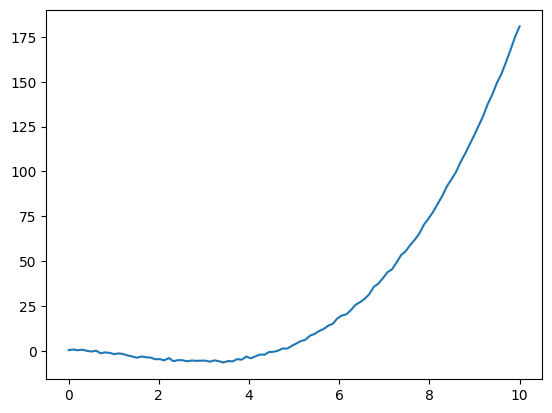

In [2]:
def f(x,theta):
    return theta[0]+theta[1]*x+theta[2]*x**2.+theta[3]*x**3.

n = 100
s = 0.5

theta_hat = np.array([1.,-2.,-1.,0.3,s])

x_n = np.linspace(0,10,n)
data = f(x_n,[1.,-2.,-1.,0.3])
noisy_data = data + np.random.normal(scale=s, size=len(data))
data_int = [(a,b) for a,b in zip(x_n,noisy_data)]

plt.plot(x_n, noisy_data)
plt.show()

In [3]:
H = -hessian_numeric(log_posterior, theta_hat)
cov_post = np.linalg.inv(H)

d = len(theta_hat)
proposal_cov = (2.4**2 / d) * cov_post

def proposal_sampler(theta_current):
    return np.random.multivariate_normal(theta_current, proposal_cov)

def proposal_pdf(theta_new, theta_old):
    return multivariate_normal.pdf(theta_new, mean=theta_old, cov=proposal_cov)

samples, acc_rate = metropolis_hastings(
    log_posterior=log_posterior,
    theta_init=theta_hat,
    n_samples=50000,
    proposal_cov=proposal_cov,
    burn_in=1000,
    thinning=2
)

print("Acceptance rate:", acc_rate)
print("Samples shape:", samples.shape)
n_nan = np.sum(np.isnan(samples))
print("Number of NaNs:", n_nan)
burnin = 10_000
posterior_sample = samples[burnin:]
N_total = len(posterior_sample)
S_vals = np.unique(
    np.logspace(2, np.log10(N_total), 12, dtype=int)
)

logZ_cj_vals = []

for S in S_vals:
    sample_S = posterior_sample[:S]
    logZ = chib_jeliazkov(sample_S, log_likelihood, log_prior_theta, log_prior_sigma,theta_star=theta_hat)
    print('Chib-Jeliazkov',logZ)
    logZ_cj_vals.append(logZ)

logZ_cjmh_vals = []

for S in S_vals:
    sample_S = posterior_sample[:S]
    logZ = chib_jeliazkov_mh(
    samples=sample_S,
    theta_star=theta_hat,
    log_likelihood=log_likelihood,
    log_prior=lambda theta: log_prior_theta(theta[:-1]) + log_prior_sigma(theta[-1]),
    proposal_sampler=proposal_sampler,
    proposal_pdf=proposal_pdf,
    n_proposals=1000
)
    print('Chib-Jeliazkov Metropolis',logZ)
    logZ_cjmh_vals.append(logZ)

logZ_perr_vals = []

for S in S_vals:
    sample_S = posterior_sample[:S]

    logZ = perrakis_estimator(sample_S, log_likelihood, log_prior_theta, log_prior_sigma)
    print('Perrakis',logZ)

    logZ_perr_vals.append(logZ)

logZ_br_vals = []

for S in S_vals:
    sample_S = posterior_sample[:S]
    logZ = bridge_sampling(sample_S, log_likelihood, log_prior_theta, log_prior_sigma)
    print('Bridge',logZ)
    logZ_br_vals.append(logZ)

bic = compute_BIC(theta_hat,n)

Acceptance rate: 0.25712871287128714
Samples shape: (50000, 5)
Number of NaNs: 0
Chib-Jeliazkov -104.04096293274203
Chib-Jeliazkov -104.00018999931996
Chib-Jeliazkov -104.10495716026912
Chib-Jeliazkov -104.28773733793466
Chib-Jeliazkov -104.32836042486542
Chib-Jeliazkov -104.22765967192919
Chib-Jeliazkov -104.35402441244
Chib-Jeliazkov -104.30003445858932
Chib-Jeliazkov -104.21725826858514
Chib-Jeliazkov -104.2677145563176
Chib-Jeliazkov -104.2656430984359
Chib-Jeliazkov -104.23350654658891
Chib-Jeliazkov Metropolis -103.76244525307928
Chib-Jeliazkov Metropolis -103.86572774374122
Chib-Jeliazkov Metropolis -103.8939705204773
Chib-Jeliazkov Metropolis -103.93363284639739
Chib-Jeliazkov Metropolis -103.9874809771472
Chib-Jeliazkov Metropolis -103.97107124519812
Chib-Jeliazkov Metropolis -103.97635935466911
Chib-Jeliazkov Metropolis -104.03413421463608
Chib-Jeliazkov Metropolis -103.92793285313374
Chib-Jeliazkov Metropolis -104.0331292932795
Chib-Jeliazkov Metropolis -104.09083201281393
C

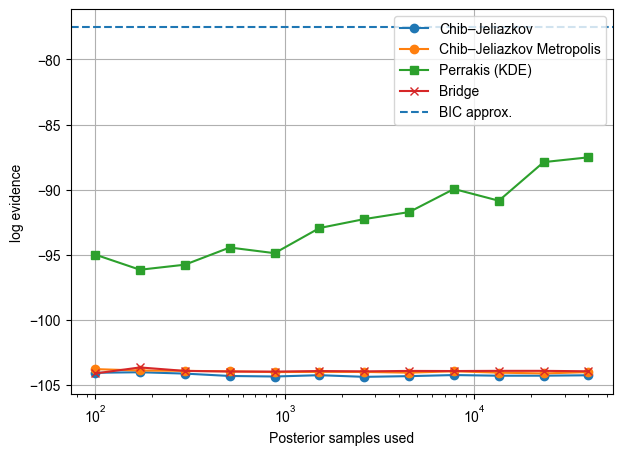

In [6]:
try:
    from matplotlib import font_manager
    font_manager.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    prop = font_manager.FontProperties(fname='/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except Exception as e:
    print('Could not load Arial font')
    print(e)

plt.figure(figsize=(7,5))
plt.plot(S_vals, logZ_cj_vals, "-o", label="Chib–Jeliazkov")
plt.plot(S_vals, logZ_cjmh_vals, "-o", label="Chib–Jeliazkov Metropolis")
plt.plot(S_vals, logZ_perr_vals, "-s", label="Perrakis (KDE)")
plt.plot(S_vals, logZ_br_vals, "-x", label="Bridge")
plt.axhline(bic,0,1, ls='--',label="BIC approx.")
plt.xscale("log")
plt.xlabel("Posterior samples used")
plt.ylabel("log evidence")
plt.legend()
plt.grid(True)
plt.savefig("benchmark_integration_methods.pdf",dpi=300)


# TERMODINAMIC INTEGRATION ESTIMATOR

In [ ]:
def log_power_posterior(theta, beta):
    return beta * log_likelihood(theta) \
           + log_prior_theta(theta[:-1]) \
           + log_prior_sigma(theta[-1])

def metropolis_power_posterior(
    theta_init,
    beta,
    n_samples,
    proposal_cov,
    burn_in=500
):
    theta = theta_init.copy()
    d = len(theta)
    samples = []
    
    logp_current = log_power_posterior(theta, beta)
    
    for i in range(n_samples + burn_in):
        theta_prop = np.random.multivariate_normal(theta, proposal_cov)
        
        logp_prop = log_power_posterior(theta_prop, beta)
        
        if np.log(np.random.rand()) < logp_prop - logp_current:
            theta = theta_prop
            logp_current = logp_prop
        
        if i >= burn_in:
            samples.append(theta.copy())
    
    return np.array(samples)

def beta_schedule(n_beta, power=4.0):
    k = np.arange(n_beta)
    return (k / (n_beta - 1)) ** power

def thermodynamic_integration(
    theta_init,
    proposal_cov,
    n_beta=30,
    n_samples_per_beta=2000,
    burn_in=500,
    beta_power=4.0
):
    betas = beta_schedule(n_beta, power=4.0)
    betas[0] = 1e-4
    expected_loglik = []
    
    theta_current = theta_init.copy()
    
    for beta in betas:
        samples = metropolis_power_posterior(
            theta_init=theta_current,
            beta=beta,
            n_samples=n_samples_per_beta,
            proposal_cov=proposal_cov,
            burn_in=burn_in
        )
        
        # Use last sample as warm start
        theta_current = samples[-1]
        
        loglik_vals = np.array([log_likelihood(theta) for theta in samples])
        expected_loglik.append(np.mean(loglik_vals))
    
    expected_loglik = np.array(expected_loglik)
    
    # Trapezoidal integration
    log_marginal = np.trapz(expected_loglik, betas)
    
    return log_marginal, betas, expected_loglik

theta_init = theta_hat  # or posterior median
proposal_cov = np.eye(len(theta_init)) * 0.05

logZ_TI, betas, ElogL = thermodynamic_integration(
    theta_init=theta_init,
    proposal_cov=proposal_cov,
    n_beta=30,
    n_samples_per_beta=2000,
    burn_in=500,
    beta_power=4.0
)

print("TI log marginal likelihood:", logZ_TI)

plt.plot(betas, ElogL, marker='o')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\mathbb{E}_\beta[\log p(y|\theta)]$')
plt.title('Thermodynamic Integration diagnostic')
plt.show()